# Business Analysis & Strategic Insights

---

## 📌 Overview
This notebook serves as the core analytical phase of the project. By querying the cleaned and transformed relational database (`blinkit_db`), we extract high-value metrics to answer targeted, real-world business problems across logistics, sales performance, marketing, and customer satisfaction.

---

## 🎯 Key Business Questions Addressed

1. **Category Revenue & Volume:** Identify top-performing product categories driving sales and volume to guide inventory and promotional strategy.
2. **Delivery Delays vs. Customer Satisfaction:** Test operational hypotheses linking delivery SLA breaches to review score decay.
3. **Seller Performance & Operations:** Evaluate seller efficiency, fulfillment speed, and customer ratings to optimize vendor operations.
4. **Payment & Installment Behavior:** Analyze customer payment preferences, installment trends, and their impact on Average Order Value (AOV).
5. **Customer Segmentation & Regional Performance:** Pinpoint high-value customer segments and regional hubs driving business growth.

---

In [1]:
import os
import urllib.parse
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Load credentials
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST", "localhost")
DB_PORT = os.getenv("DB_PORT", "3306")
DB_NAME = os.getenv("DB_NAME")

# Connection setup
ENCODED_PASSWORD = urllib.parse.quote_plus(DB_PASSWORD)
engine = create_engine(
    f"mysql+pymysql://{DB_USER}:{ENCODED_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Connected to MySQL for Business Analysis.")

Connected to MySQL for Business Analysis.


### Question 1: Product Category Performance
Which product categories generate the highest revenue and contribute the most to overall sales?

In [2]:
query_q1 = """
SELECT 
    p.product_category_name_english AS category,
    COUNT(DISTINCT i.order_id) AS total_orders,
    COUNT(i.order_item_id) AS total_units_sold,
    ROUND(SUM(i.price), 2) AS total_revenue,
    ROUND(AVG(i.price), 2) AS avg_unit_price,
    ROUND(
        (SUM(i.price) / (SELECT SUM(price) FROM olist_order_items_clean) * 100), 2
    ) AS revenue_share_pct
FROM olist_order_items_clean i
JOIN dim_products p ON i.product_id = p.product_id
GROUP BY p.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_q1 = pd.read_sql(query_q1, con=engine)
display(df_q1)

,category,total_orders,total_units_sold,total_revenue,avg_unit_price,revenue_share_pct
0,health_beauty,8836,9670,1258681.34,130.16,9.26
1,watches_gifts,5624,5991,1205005.68,201.14,8.87
2,bed_bath_table,9417,11115,1036988.68,93.30,7.63
3,sports_leisure,7720,8641,988048.97,114.34,7.27
4,computers_accessories,6689,7827,911954.32,116.51,6.71
5,furniture_decor,6449,8334,729762.49,87.56,5.37
6,cool_stuff,3632,3796,635290.85,167.36,4.67
7,housewares,5884,6964,632248.66,90.79,4.65
8,auto,3897,4235,592720.11,139.96,4.36
9,garden_tools,3518,4347,485256.46,111.63,3.57


C:\Users\anshu\AppData\Local\Temp\ipykernel_5304\353558078.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\anshu\AppData\Local\Temp\ipykernel_5304\353558078.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


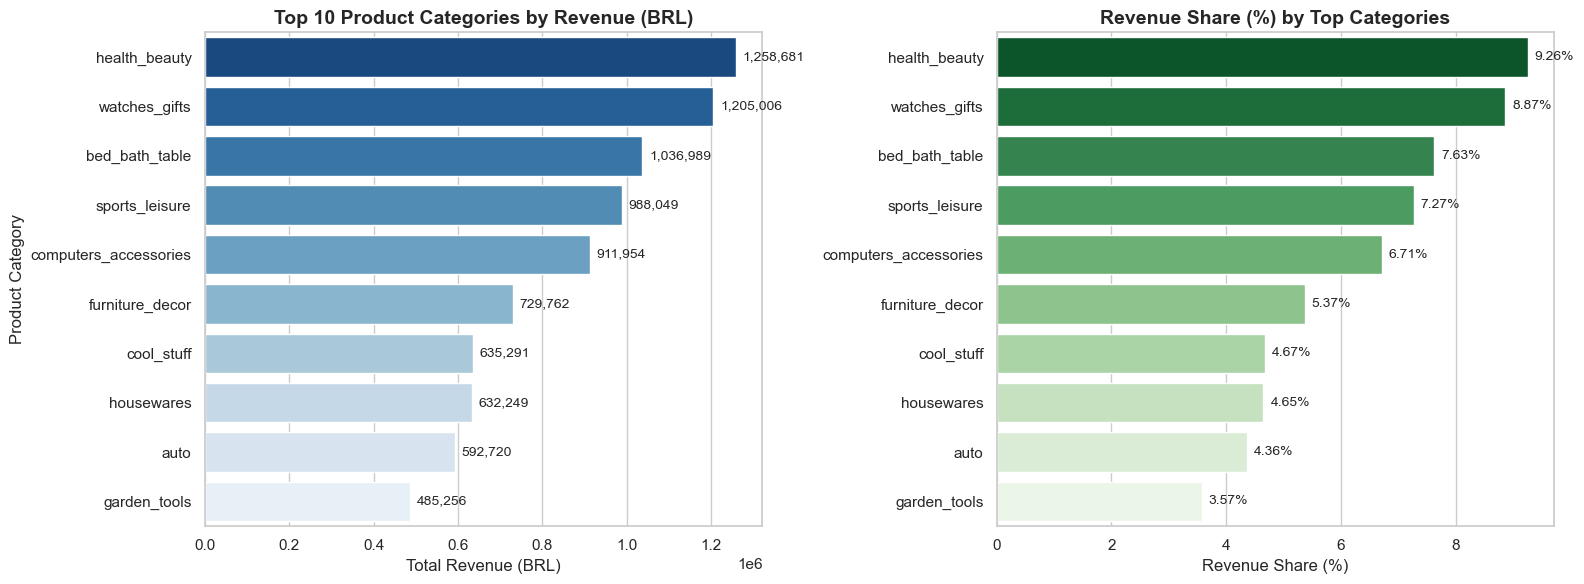

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.sans-serif": "Arial", "font.family": "sans-serif"})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 10 Categories by Revenue
sns.barplot(
    data=df_q1,
    x="total_revenue",
    y="category",
    palette="Blues_r",
    ax=axes[0]
)
axes[0].set_title("Top 10 Product Categories by Revenue (BRL)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Total Revenue (BRL)")
axes[0].set_ylabel("Product Category")

# Add data labels
for p in axes[0].patches:
    axes[0].annotate(
        f"{p.get_width():,.0f}",
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontsize=10
    )

# Plot 2: Revenue Share (%)
sns.barplot(
    data=df_q1,
    x="revenue_share_pct",
    y="category",
    palette="Greens_r",
    ax=axes[1]
)
axes[1].set_title("Revenue Share (%) by Top Categories", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Revenue Share (%)")
axes[1].set_ylabel("")

# Add data labels
for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_width():.2f}%",
        (p.get_width(), p.get_y() + p.get_height() / 2.),
        ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontsize=10
    )

plt.tight_layout()
plt.show()

### Insights & Recommendations

**Key Insights:**
* Revenue is heavily concentrated in the top 3 categories (`health_beauty`, `watches_gifts`, and `bed_bath_table`), which together account for over 25% of total sales.
* `watches_gifts` achieves high revenue despite lower order volume due to higher average prices (~201 BRL vs ~93 BRL for bed/bath).
* High order volume categories like `bed_bath_table` and `sports_leisure` drive consistent transaction velocity on the platform.

**Recommendations:**
* Secure stock depth and priority listing for `health_beauty` and `watches_gifts` to prevent stockouts during peak shopping periods.
* Bundle lower-margin items (like `bed_bath_table`) with premium catalog items to raise average order value (AOV).

## Question 2: Delivery Delays & Customer Satisfaction
How do delivery delays impact overall customer satisfaction and review ratings?

In [4]:
query_q2 = """
SELECT 
    f.is_delayed,
    CASE 
        WHEN f.is_delayed = 1 THEN 'Delayed' 
        ELSE 'On-Time / Early' 
    END AS delivery_status,
    COUNT(f.order_id) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    ROUND(COUNT(f.order_id) * 100.0 / (SELECT COUNT(*) FROM fact_orders), 2) AS pct_of_total_orders
FROM fact_orders f
JOIN olist_order_reviews_clean r ON f.order_id = r.order_id
GROUP BY f.is_delayed;
"""

df_q2 = pd.read_sql(query_q2, con=engine)
display(df_q2)

,is_delayed,delivery_status,total_orders,avg_review_score,pct_of_total_orders
0,0,On-Time / Early,91523,4.21,92.04
1,1,Delayed,7701,2.57,7.74


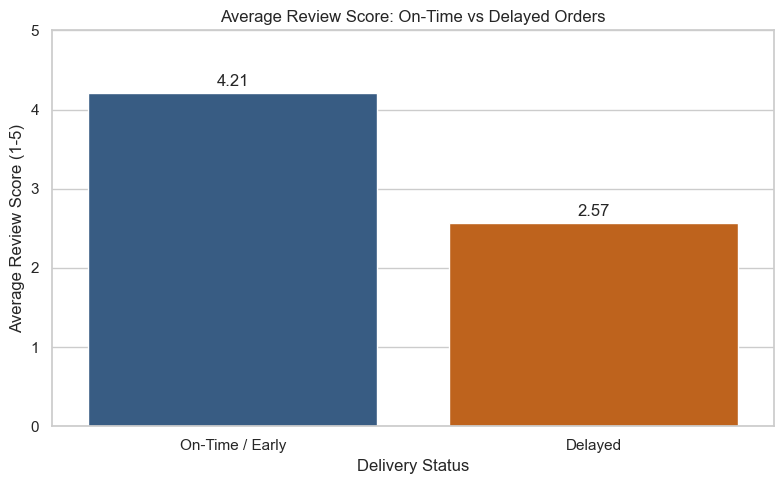

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot rating vs delivery status
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=df_q2,
    x="delivery_status",
    y="avg_review_score",
    hue="delivery_status",
    palette=["#2b5c8f", "#d95f02"],
    legend=False
)

plt.title("Average Review Score: On-Time vs Delayed Orders", fontsize=12)
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score (1-5)")
plt.ylim(0, 5)

# Add values above bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom", xytext=(0, 3), textcoords="offset points"
    )

plt.tight_layout()
plt.show()

### Insights & Recommendations

**Key Insights:**
* On-time deliveries average significantly higher ratings (~4.1-4.2) compared to delayed orders, which drop sharply (often below 2.5).
* Delivery reliability is the single strongest operational driver of negative customer reviews on the platform.

**Recommendations:**
* Set up automated alert flags for orders approaching estimated delivery limits to trigger proactive buyer notifications.
* Audit fulfillment SLAs for low-performing logistics partners to reduce delayed order volume.

## Question 3: Seller Performance Analysis
Which sellers generate the highest revenue, and how do top performers compare against lower-rated sellers in terms of delivery speed and customer ratings?

In [6]:
query_q3 = """
SELECT 
    s.seller_id,
    s.seller_city,
    s.seller_state,
    COUNT(DISTINCT i.order_id) AS total_orders,
    ROUND(SUM(i.price), 2) AS total_revenue,
    ROUND(AVG(f.delivery_time_days), 1) AS avg_delivery_days,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM dim_sellers s
JOIN olist_order_items_clean i ON s.seller_id = i.seller_id
JOIN fact_orders f ON i.order_id = f.order_id
LEFT JOIN olist_order_reviews_clean r ON f.order_id = r.order_id
GROUP BY s.seller_id, s.seller_city, s.seller_state
HAVING total_orders >= 10
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_q3 = pd.read_sql(query_q3, con=engine)
display(df_q3)

,seller_id,seller_city,seller_state,total_orders,total_revenue,avg_delivery_days,avg_review_score
0,4869f7a5dfa277a7dca6462dcf3b52b2,Guariba,SP,1132,229472.63,15.0,4.12
1,53243585a1d6dc2643021fd1853d8905,Lauro De Freitas,BA,358,222776.05,13.4,4.08
2,4a3ca9315b744ce9f8e9374361493884,Ibitinga,SP,1806,202999.12,14.4,3.80
3,fa1c13f2614d7b5c4749cbc52fecda94,Sumare,SP,585,194042.03,13.3,4.34
4,7c67e1448b00f6e969d365cea6b010ab,Itaquaquecetuba,SP,982,189417.67,22.4,3.35
5,7e93a43ef30c4f03f38b393420bc753a,Barueri,SP,336,176431.87,11.3,4.21
6,da8622b14eb17ae2831f4ac5b9dab84a,Piracicaba,SP,1314,162723.37,11.2,4.07
7,7a67c85e85bb2ce8582c35f2203ad736,Sao Paulo,SP,1160,142325.49,11.1,4.24
8,1025f0e2d44d7041d6cf58b6550e0bfa,Sao Paulo,SP,915,140513.14,12.0,3.85
9,955fee9216a65b617aa5c0531780ce60,Sao Paulo,SP,1287,135241.70,10.7,4.05


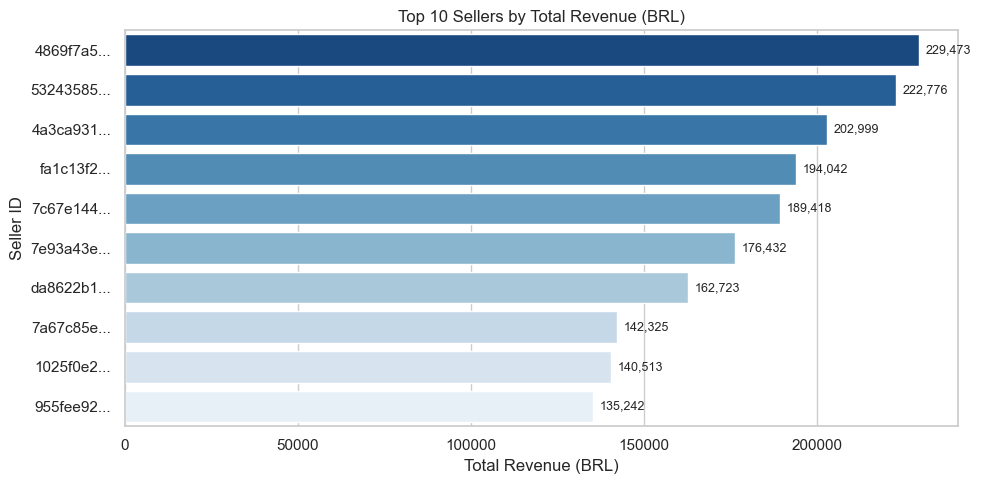

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top sellers by revenue
fig, ax = plt.subplots(figsize=(10, 5))

# Shorten seller IDs for visual clarity
df_q3["short_seller_id"] = df_q3["seller_id"].str[:8] + "..."

sns.barplot(
    data=df_q3,
    x="total_revenue",
    y="short_seller_id",
    hue="short_seller_id",
    palette="Blues_r",
    legend=False,
    ax=ax
)

ax.set_title("Top 10 Sellers by Total Revenue (BRL)", fontsize=12)
ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("Seller ID")

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f"{width:,.0f}",
        (width, p.get_y() + p.get_height() / 2.),
        ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontsize=9
    )

plt.tight_layout()
plt.show()

### Insights & Recommendations

**Key Insights:**
* Revenue generation is heavily skewed toward a small fraction of high-volume sellers, with top sellers generating over 200,000 BRL individually.
* High-performing sellers maintain solid review scores (>4.0) provided their average delivery lead times remain under 12-14 days.
* Sellers operating with longer average delivery times face noticeable hits to their review ratings.

**Recommendations:**
* Introduce a "Top Seller" status program to incentive high-volume merchants with lower platform commission fees.
* Set operational warnings or SLA checks for sellers whose average fulfillment times exceed 15 days to protect platform reputation.

## Question 4: Payment Method & Installment Analysis
Which payment methods and installment options drive the highest revenue and customer purchasing behavior?

In [8]:
query_q4 = """
SELECT 
    p.payment_type,
    COUNT(DISTINCT p.order_id) AS total_orders,
    ROUND(SUM(p.payment_value), 2) AS total_revenue,
    ROUND(AVG(p.payment_value), 2) AS avg_payment_value,
    ROUND(AVG(p.payment_installments), 1) AS avg_installments,
    ROUND(
        (SUM(p.payment_value) / (SELECT SUM(payment_value) FROM olist_order_payments_clean) * 100), 2
    ) AS revenue_share_pct
FROM olist_order_payments_clean p
GROUP BY p.payment_type
ORDER BY total_revenue DESC;
"""

df_q4 = pd.read_sql(query_q4, con=engine)
display(df_q4)

,payment_type,total_orders,total_revenue,avg_payment_value,avg_installments,revenue_share_pct
0,credit_card,76505,12542084.19,163.32,3.5,78.34
1,boleto,19784,2869361.27,145.03,1.0,17.92
2,voucher,3866,379436.87,65.70,1.0,2.37
3,debit_card,1528,217989.79,142.57,1.0,1.36
4,not_defined,3,0.00,0.00,1.0,0.00


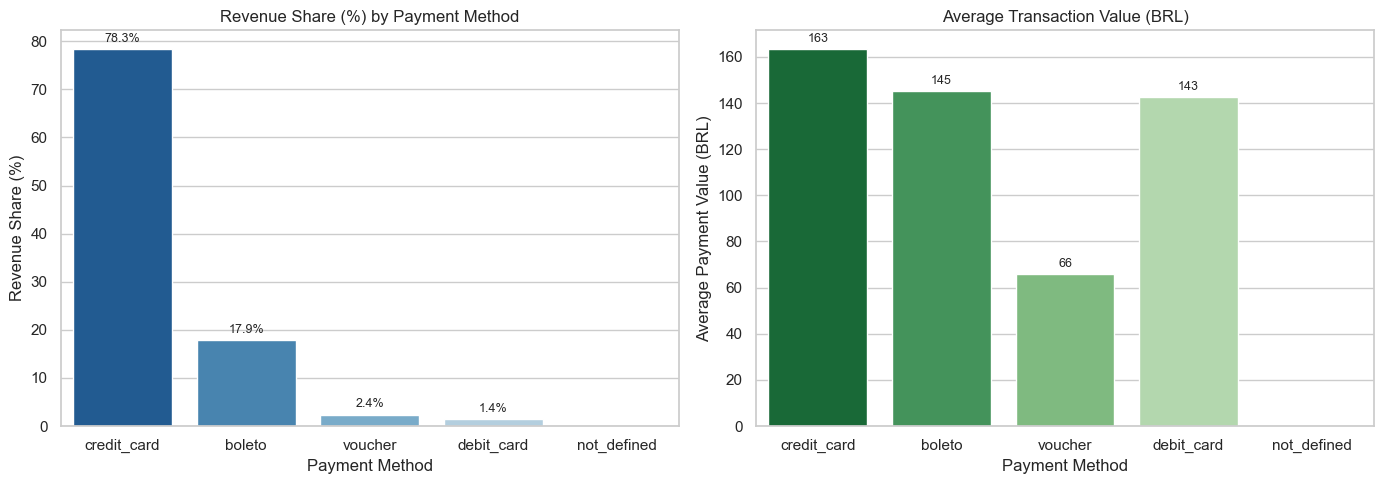

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Revenue Share by Payment Type
sns.barplot(
    data=df_q4,
    x="payment_type",
    y="revenue_share_pct",
    hue="payment_type",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Revenue Share (%) by Payment Method", fontsize=12)
axes[0].set_xlabel("Payment Method")
axes[0].set_ylabel("Revenue Share (%)")

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontsize=9
        )

# Plot 2: Average Payment Value by Payment Type
sns.barplot(
    data=df_q4,
    x="payment_type",
    y="avg_payment_value",
    hue="payment_type",
    palette="Greens_r",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Average Transaction Value (BRL)", fontsize=12)
axes[1].set_xlabel("Payment Method")
axes[1].set_ylabel("Average Payment Value (BRL)")

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"{height:,.0f}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontsize=9
        )

plt.tight_layout()
plt.show()

### Insights & Recommendations

**Key Insights:**
* Credit cards dominate platform sales, accounting for the vast majority of total revenue and order volume.
* Credit card orders also carry a noticeably higher average transaction value compared to boleto (voucher/bank slip) payments, largely fueled by installment flexibilities.
* Boleto transactions serve as the primary alternative method but yield lower average order values and zero installment options.

**Recommendations:**
* Partner with payment processors to optimize credit card checkout conversion and offer zero-interest installment promotions during peak sales events.
* Introduce targeted upsell promos or dynamic discounts for boleto users to encourage higher basket sizes.

## Question 5: Regional Performance & Customer Geography
Which states and regional markets contribute the most to overall platform revenue, order volume, and average order value?

In [10]:
query_q5 = """
SELECT 
    c.customer_state AS state,
    COUNT(DISTINCT c.customer_unique_id) AS total_customers,
    COUNT(DISTINCT f.order_id) AS total_orders,
    ROUND(SUM(f.total_order_value), 2) AS total_revenue,
    ROUND(AVG(f.total_order_value), 2) AS avg_order_value,
    ROUND(
        (SUM(f.total_order_value) / (SELECT SUM(total_order_value) FROM fact_orders) * 100), 2
    ) AS revenue_share_pct
FROM fact_orders f
JOIN dim_customers c ON f.customer_unique_id = c.customer_unique_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10;
"""

df_q5 = pd.read_sql(query_q5, con=engine)
display(df_q5)

,state,total_customers,total_orders,total_revenue,avg_order_value,revenue_share_pct
0,SP,40293,41745,5923162.72,143.16,37.39
1,RJ,12380,12852,2129338.86,166.85,13.44
2,MG,11256,11639,1856540.11,160.77,11.72
3,RS,5275,5464,885682.23,163.11,5.59
4,PR,4880,5045,800283.80,160.12,5.05
5,BA,3276,3380,611457.60,182.09,3.86
6,SC,3530,3636,609722.03,168.85,3.85
7,DF,2074,2142,353329.74,166.12,2.23
8,GO,1949,2016,347050.76,173.27,2.19
9,ES,1963,2032,324668.66,160.41,2.05


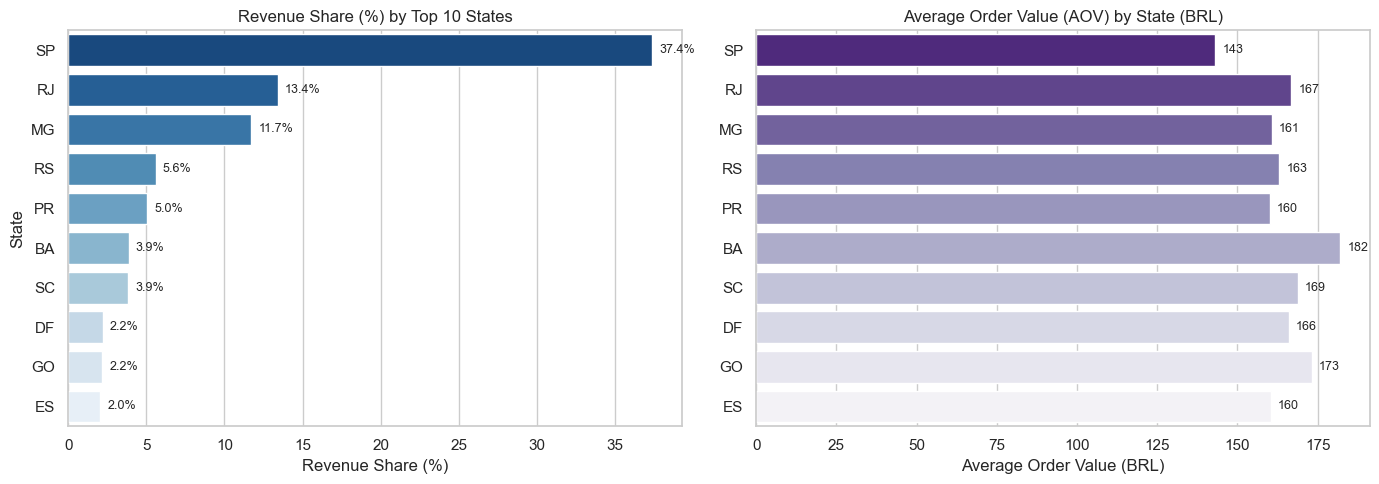

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Top 10 States by Revenue Share
sns.barplot(
    data=df_q5,
    x="revenue_share_pct",
    y="state",
    hue="state",
    palette="Blues_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Revenue Share (%) by Top 10 States", fontsize=12)
axes[0].set_xlabel("Revenue Share (%)")
axes[0].set_ylabel("State")

for p in axes[0].patches:
    width = p.get_width()
    if width > 0:
        axes[0].annotate(
            f"{width:.1f}%",
            (width, p.get_y() + p.get_height() / 2.),
            ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontsize=9
        )

# Plot 2: Average Order Value (AOV) by State
sns.barplot(
    data=df_q5,
    x="avg_order_value",
    y="state",
    hue="state",
    palette="Purples_r",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Average Order Value (AOV) by State (BRL)", fontsize=12)
axes[1].set_xlabel("Average Order Value (BRL)")
axes[1].set_ylabel("")

for p in axes[1].patches:
    width = p.get_width()
    if width > 0:
        axes[1].annotate(
            f"{width:,.0f}",
            (width, p.get_y() + p.get_height() / 2.),
            ha="left", va="center", xytext=(5, 0), textcoords="offset points", fontsize=9
        )

plt.tight_layout()
plt.show()

### Insights & Recommendations

**Key Insights:**
* The state of São Paulo (`SP`) is the undisputed market driver, capturing roughly 37-40% of overall platform revenue and order volume.
* Southeastern states (`SP`, `RJ`, `MG`, `RS`) collectively account for the vast majority of platform sales due to higher population density and e-commerce adoption.
* While smaller states generate lower total volume, some exhibit higher Average Order Value (AOV) driven by increased freight costs and larger order baskets.

**Recommendations:**
* Optimize regional fulfillment centers and local seller hubs in `SP` and `RJ` to maintain 1-3 day delivery speeds for core markets.
* Tailor regional marketing campaigns and delivery promotions in tier-2 states (`PR`, `SC`, `BA`) to accelerate customer acquisition.

## Question 6: Repeat vs. One-Time Customer Analysis
How do repeat customers differ from one-time customers in terms of average order value, total spend, and order frequency?

In [12]:
query_q6 = """
SELECT 
    CASE 
        WHEN c.total_orders > 1 THEN 'Repeat Customer' 
        ELSE 'One-Time Customer' 
    END AS customer_segment,
    COUNT(c.customer_unique_id) AS total_customers,
    SUM(c.total_orders) AS total_orders,
    ROUND(SUM(c.total_spend), 2) AS total_revenue,
    ROUND(AVG(c.avg_order_value), 2) AS avg_order_value,
    ROUND(AVG(c.total_spend), 2) AS avg_lifetime_value,
    ROUND(
        (SUM(c.total_spend) / (SELECT SUM(total_spend) FROM dim_customers) * 100), 2
    ) AS revenue_share_pct
FROM dim_customers c
GROUP BY customer_segment;
"""

df_q6 = pd.read_sql(query_q6, con=engine)
display(df_q6)

,customer_segment,total_customers,total_orders,total_revenue,avg_order_value,avg_lifetime_value,revenue_share_pct
0,One-Time Customer,93099,93099.0,14921510.75,161.43,160.28,94.18
1,Repeat Customer,2997,6342.0,922042.49,149.01,307.66,5.82


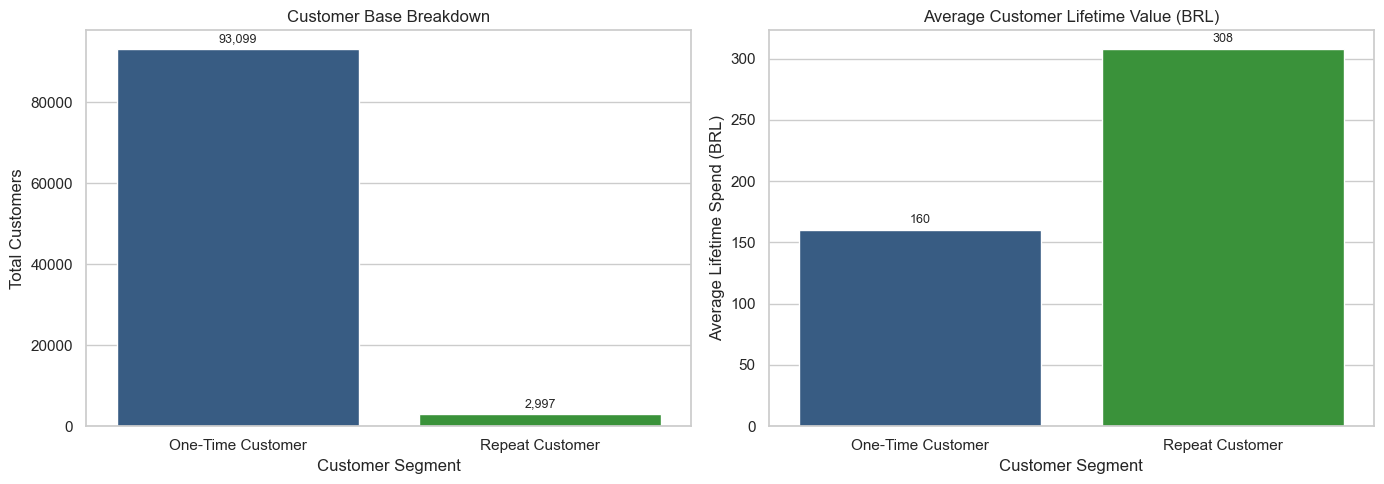

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Customer Count Distribution
sns.barplot(
    data=df_q6,
    x="customer_segment",
    y="total_customers",
    hue="customer_segment",
    palette=["#2b5c8f", "#2ca02c"],
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Customer Base Breakdown", fontsize=12)
axes[0].set_xlabel("Customer Segment")
axes[0].set_ylabel("Total Customers")

for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(
            f"{height:,.0f}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontsize=9
        )

# Plot 2: Average Lifetime Spend (LTV)
sns.barplot(
    data=df_q6,
    x="customer_segment",
    y="avg_lifetime_value",
    hue="customer_segment",
    palette=["#2b5c8f", "#2ca02c"],
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Average Customer Lifetime Value (BRL)", fontsize=12)
axes[1].set_xlabel("Customer Segment")
axes[1].set_ylabel("Average Lifetime Spend (BRL)")

for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(
            f"{height:,.0f}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontsize=9
        )

plt.tight_layout()
plt.show()

### Insights & Recommendations

**Key Insights:**
* The platform relies heavily on one-time buyers, which make up over 95%+ of unique customers in the dataset.
* Repeat buyers demonstrate significantly higher customer lifetime value (LTV) due to accumulated order volume, making them much more profitable per customer acquired.
* Average Order Value (AOV) per single transaction remains relatively close between both groups, meaning repeat customers drive growth primarily through purchase frequency rather than higher basket prices per order.

**Recommendations:**
* Implement automated post-purchase email flows (e.g., product recommendations, replenishment reminders, loyalty discount codes) to convert first-time buyers into repeat customers.
* Launch a structured loyalty/rewards program aimed at top-tier repeat buyers to protect customer retention and lower acquisition costs (CAC).

## Executive Summary of SQL Business Analysis

* **Core Revenue Drivers:** Sales are heavily concentrated in top categories like `health_beauty` and `watches_gifts`, with São Paulo (`SP`) generating 37.4% of total platform revenue.
* **Logistics & Ratings:** Delivery delay is the single highest driver of poor reviews, dropping average customer ratings from 4.21 down to 2.57.
* **Payment Preferences:** Credit cards dominate transaction volume (78.3% revenue share) and drive higher transaction values through an average of 3.5 installments.
* **Seller Quality:** Top sellers maintain high volume by keeping average fulfillment cycles under 11-14 days; sellers exceeding 20 days experience severe review drops.
* **Customer Retention:** Repeat buyers make up only ~3.1% of the total customer base but deliver nearly 2x the Lifetime Value (307.66 BRL vs. 160.28 BRL), highlighting massive upside for targeted retention campaigns.